# Loading Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
import warnings
warnings.filterwarnings(action = 'ignore')
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import Lasso,LinearRegression,ElasticNet,Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score,cross_val_predict
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import xgboost
import optuna

# Loading Data

In [2]:
data = pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv')

In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
print(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [6]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


# Pre Processing

In [7]:
def convert_categorical_to_numerical(data,unique_val = 10):
    obj_df = data.select_dtypes(include=[object])
    unique_list = [f for f in obj_df.columns if obj_df[f].unique().shape[0]>=unique_val]
    print(unique_list)
    obj_df_sel = obj_df.drop(columns=unique_list)
    for col in obj_df_sel.columns:
        data[col] = pd.factorize(data[col])[0]
    print("conversion successfull")
    return data

def auto_data_impute(data,get_rid_percent=2):
    for x,y in data.isnull().sum().items():
        percent = y/data.shape[0]
        if percent <= get_rid_percent/100:
            data[x]  = data[x].fillna(data[x].mean())
        else:
            print("removed column : ",x)
            data = data.drop([x],axis=1)
    print("Data imputation successfull")
    return data

def scaling_data(data,target):
    num_df = data.select_dtypes(include = [int,float])
    for i in num_df:
        sc = StandardScaler()
        if i!=target:
            data[i] = sc.fit_transform(data[i].values.reshape(-1,1))
    print("scaling was successfull")
    return data

In [8]:
# Dropping ID Column
data.drop('Id',1,inplace = True)
pid = test.Id
test.drop('Id',1,inplace = True)

<h2> Training Data

In [9]:
train = scaling_data(data,target = 'SalePrice')

scaling was successfull


In [10]:
train = convert_categorical_to_numerical(data)

['Neighborhood', 'Exterior1st', 'Exterior2nd']
conversion successfull


In [11]:
train

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0.073375,0,-0.208034,-0.207142,0,-1,0,0,0,0,...,-0.068692,-1,-1,-1,-0.087688,-1.599111,0.138777,0,0,208500
1,-0.872563,0,0.409895,-0.091886,0,-1,0,0,0,1,...,-0.068692,-1,-1,-1,-0.087688,-0.489110,-0.614439,0,0,181500
2,0.073375,0,-0.084449,0.073480,0,-1,1,0,0,0,...,-0.068692,-1,-1,-1,-0.087688,0.990891,0.138777,0,0,223500
3,0.309859,0,-0.414011,-0.096897,0,-1,1,0,0,2,...,-0.068692,-1,-1,-1,-0.087688,-1.599111,-1.367655,0,1,140000
4,0.073375,0,0.574676,0.375148,0,-1,1,0,0,1,...,-0.068692,-1,-1,-1,-0.087688,2.100892,0.138777,0,0,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,0.073375,0,-0.331620,-0.260560,0,-1,0,0,0,0,...,-0.068692,-1,-1,-1,-0.087688,0.620891,-0.614439,0,0,175000
1456,-0.872563,0,0.615871,0.266407,0,-1,0,0,0,0,...,-0.068692,-1,0,-1,-0.087688,-1.599111,1.645210,0,0,210000
1457,0.309859,0,-0.166839,-0.147810,0,-1,0,0,0,0,...,-0.068692,-1,2,0,4.953112,-0.489110,1.645210,0,0,266500
1458,-0.872563,0,-0.084449,-0.080160,0,-1,0,0,0,0,...,-0.068692,-1,-1,-1,-0.087688,-0.859110,1.645210,0,0,142125


In [12]:
le = LabelEncoder()
train['Neighborhood'] = le.fit_transform(train['Neighborhood'])
train['Exterior1st'] = le.fit_transform(train['Exterior1st'])
train['Exterior2nd'] = le.fit_transform(train['Exterior2nd'])


In [13]:
train = auto_data_impute(train)

removed column :  LotFrontage
removed column :  GarageYrBlt
Data imputation successfull


In [14]:
train

,MSSubClass,MSZoning,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0.073375,0,-0.207142,0,-1,0,0,0,0,0,...,-0.068692,-1,-1,-1,-0.087688,-1.599111,0.138777,0,0,208500
1,-0.872563,0,-0.091886,0,-1,0,0,0,1,0,...,-0.068692,-1,-1,-1,-0.087688,-0.489110,-0.614439,0,0,181500
2,0.073375,0,0.073480,0,-1,1,0,0,0,0,...,-0.068692,-1,-1,-1,-0.087688,0.990891,0.138777,0,0,223500
3,0.309859,0,-0.096897,0,-1,1,0,0,2,0,...,-0.068692,-1,-1,-1,-0.087688,-1.599111,-1.367655,0,1,140000
4,0.073375,0,0.375148,0,-1,1,0,0,1,0,...,-0.068692,-1,-1,-1,-0.087688,2.100892,0.138777,0,0,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,0.073375,0,-0.260560,0,-1,0,0,0,0,0,...,-0.068692,-1,-1,-1,-0.087688,0.620891,-0.614439,0,0,175000
1456,-0.872563,0,0.266407,0,-1,0,0,0,0,0,...,-0.068692,-1,0,-1,-0.087688,-1.599111,1.645210,0,0,210000
1457,0.309859,0,-0.147810,0,-1,0,0,0,0,0,...,-0.068692,-1,2,0,4.953112,-0.489110,1.645210,0,0,266500
1458,-0.872563,0,-0.080160,0,-1,0,0,0,0,0,...,-0.068692,-1,-1,-1,-0.087688,-0.859110,1.645210,0,0,142125


<h2> Testing Data

In [15]:
test = scaling_data(test,None)

scaling was successfull


In [16]:
test = convert_categorical_to_numerical(test)

['Neighborhood', 'Exterior1st', 'Exterior2nd', 'SaleType']
conversion successfull


In [17]:
le = LabelEncoder()
test['Neighborhood'] = le.fit_transform(test['Neighborhood'])
test['Exterior1st'] = le.fit_transform(test['Exterior1st'])
test['Exterior2nd'] = le.fit_transform(test['Exterior2nd'])
test['SaleType'] = le.fit_transform(test['SaleType'])

In [18]:
test = auto_data_impute(test)

removed column :  LotFrontage
removed column :  GarageYrBlt
Data imputation successfull


<h3> Verifying if both train and test set have the same columns

In [19]:
print(train.columns)
print(test.columns)

Index(['MSSubClass', 'MSZoning', 'LotArea', 'Street', 'Alley', 'LotShape',
       'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageCars', 'GarageArea',
       'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'Enc

In [20]:
train

,MSSubClass,MSZoning,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0.073375,0,-0.207142,0,-1,0,0,0,0,0,...,-0.068692,-1,-1,-1,-0.087688,-1.599111,0.138777,0,0,208500
1,-0.872563,0,-0.091886,0,-1,0,0,0,1,0,...,-0.068692,-1,-1,-1,-0.087688,-0.489110,-0.614439,0,0,181500
2,0.073375,0,0.073480,0,-1,1,0,0,0,0,...,-0.068692,-1,-1,-1,-0.087688,0.990891,0.138777,0,0,223500
3,0.309859,0,-0.096897,0,-1,1,0,0,2,0,...,-0.068692,-1,-1,-1,-0.087688,-1.599111,-1.367655,0,1,140000
4,0.073375,0,0.375148,0,-1,1,0,0,1,0,...,-0.068692,-1,-1,-1,-0.087688,2.100892,0.138777,0,0,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,0.073375,0,-0.260560,0,-1,0,0,0,0,0,...,-0.068692,-1,-1,-1,-0.087688,0.620891,-0.614439,0,0,175000
1456,-0.872563,0,0.266407,0,-1,0,0,0,0,0,...,-0.068692,-1,0,-1,-0.087688,-1.599111,1.645210,0,0,210000
1457,0.309859,0,-0.147810,0,-1,0,0,0,0,0,...,-0.068692,-1,2,0,4.953112,-0.489110,1.645210,0,0,266500
1458,-0.872563,0,-0.080160,0,-1,0,0,0,0,0,...,-0.068692,-1,-1,-1,-0.087688,-0.859110,1.645210,0,0,142125


In [21]:
test

,MSSubClass,MSZoning,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,-0.874711,0,0.363929,0,-1,0,0,0,0,0,...,1.818960,-0.057227,-1,0,-1,-0.092244,-0.038281,1.713905,8,0
1,-0.874711,1,0.897861,0,-1,1,0,0,1,0,...,-0.301543,-0.057227,-1,-1,0,19.730438,-0.038281,1.713905,8,0
2,0.061351,1,0.809646,0,-1,1,0,0,0,0,...,-0.301543,-0.057227,-1,0,-1,-0.092244,-1.140614,1.713905,8,0
3,0.061351,1,0.032064,0,-1,1,0,0,0,0,...,-0.301543,-0.057227,-1,-1,-1,-0.092244,-0.038281,1.713905,8,0
4,1.465443,1,-0.971808,0,-1,1,1,0,0,0,...,2.243060,-0.057227,-1,-1,-1,-0.092244,-1.875504,1.713905,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2.401505,2,-1.591330,0,-1,0,0,0,0,0,...,-0.301543,-0.057227,-1,-1,-1,-0.092244,-0.038281,-1.359958,8,0
1455,2.401505,2,-1.599808,0,-1,0,0,0,0,0,...,-0.301543,-0.057227,-1,-1,-1,-0.092244,-0.773170,-1.359958,8,2
1456,-0.874711,1,2.055150,0,-1,0,0,0,0,0,...,-0.301543,-0.057227,-1,-1,-1,-0.092244,1.064053,-1.359958,8,2
1457,0.646389,1,0.125527,0,-1,0,0,0,0,0,...,-0.301543,-0.057227,-1,0,1,1.017827,0.329164,-1.359958,8,0


# Exploring the dataset

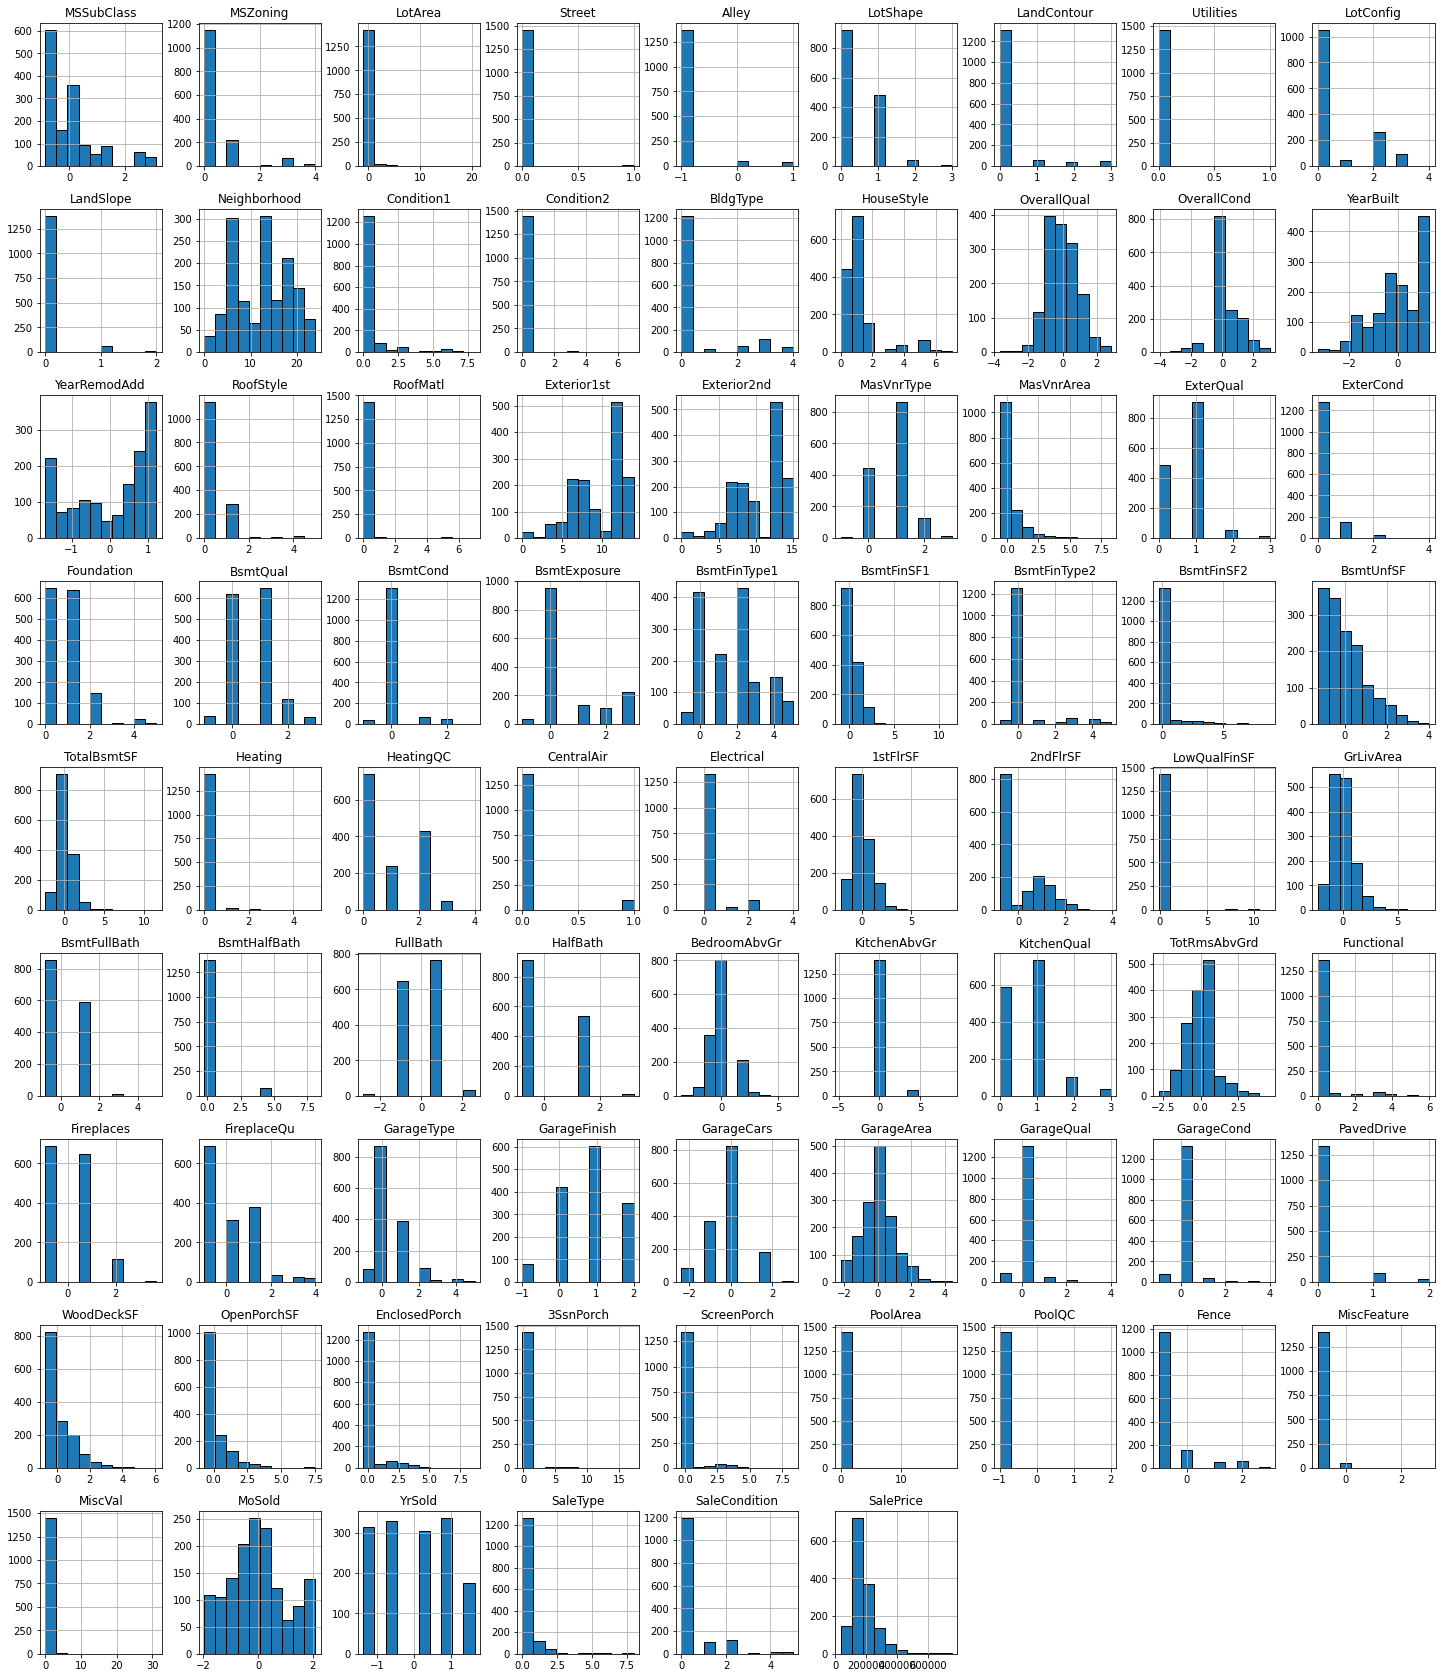

In [22]:
train.hist(figsize = (25,30),edgecolor = 'black');

<AxesSubplot:>

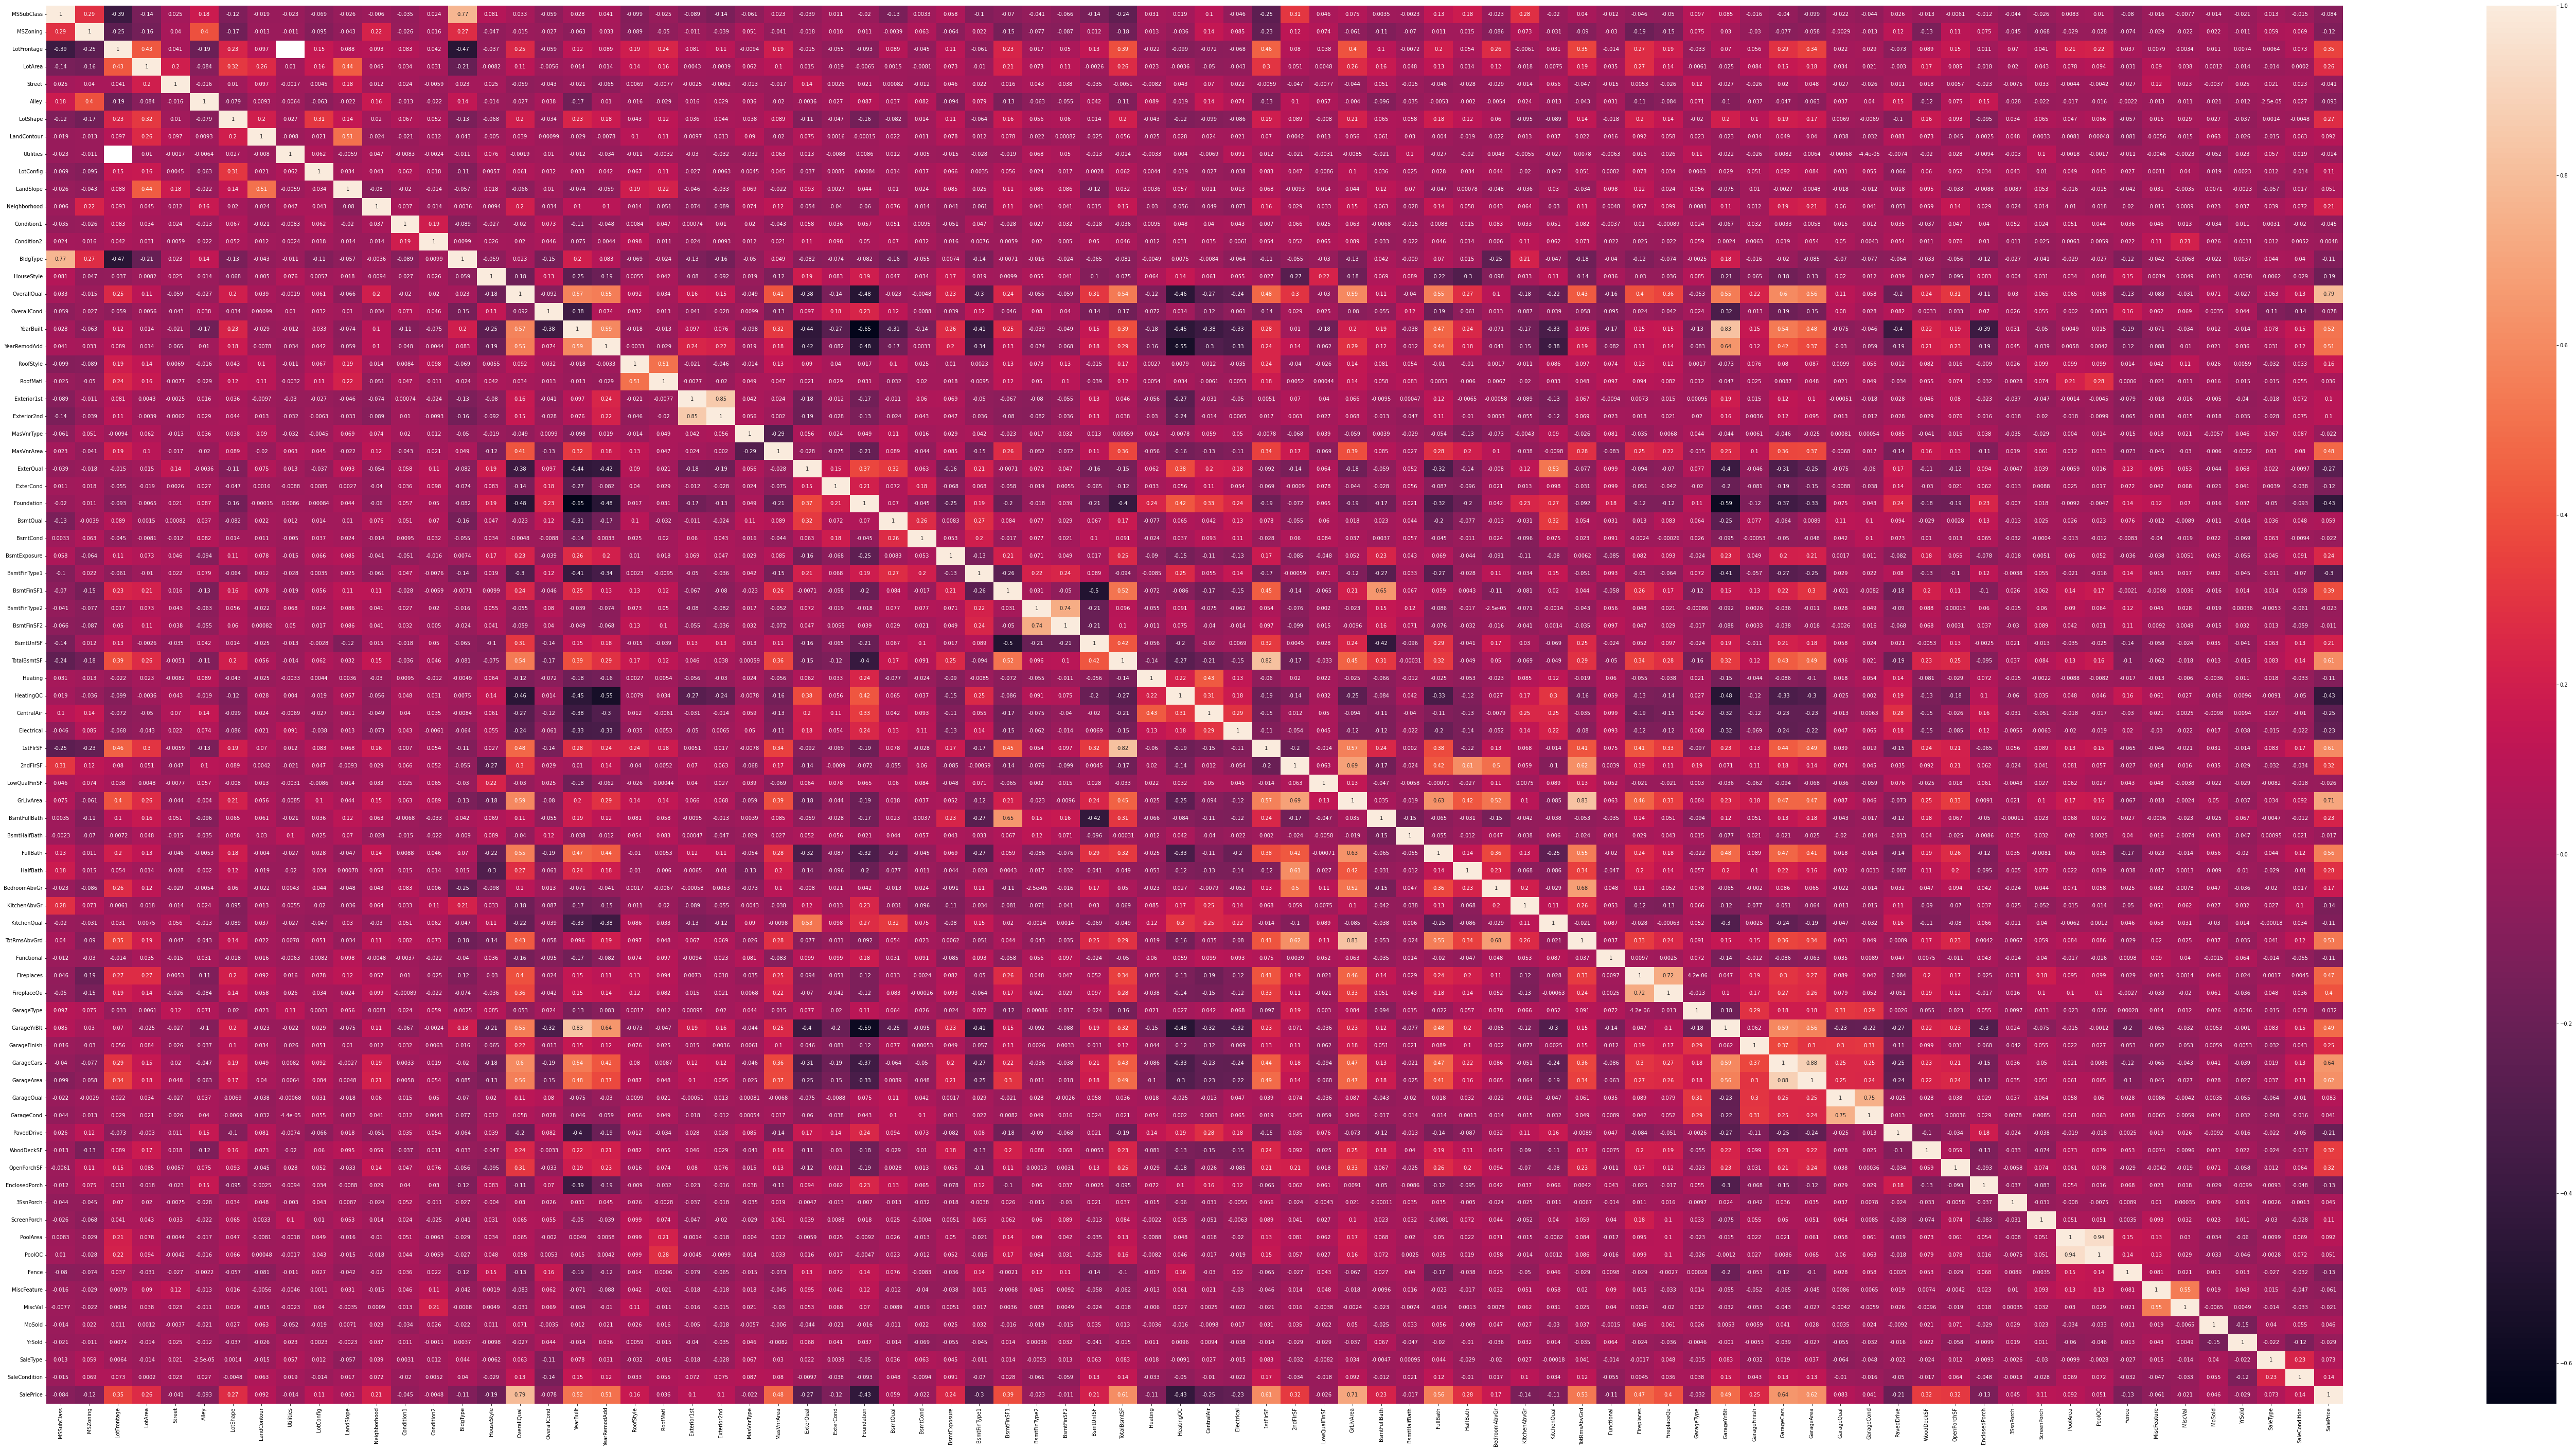

In [23]:
plt.figure(figsize = (100,50))
sb.heatmap(data.corr(),annot = True)

<h1> Preprocessing for machine learning model </h1>

In [24]:
X = train.iloc[:,:77]
y = train['SalePrice']

In [25]:
x_train,x_part,y_train,y_part = train_test_split(X,y,test_size = 0.30,random_state = 1)
x_test,x_valid,y_test,y_valid = train_test_split(x_part,y_part,test_size = 0.10,random_state = 1)

<h1> Model Selection </h1>

In [26]:
def model_performance(model,model_name,x_train = x_train,y_train = y_train,x_test = x_test,y_test = y_test,x_valid = x_valid,y_valid = y_valid):
    
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    y_val_pred = model.predict(x_valid)
    
    Training_Score = np.round(model.score(x_train,y_train),3)
    Testing_Score = np.round(model.score(x_test,y_test),3)
    Validation_score = np.round(model.score(x_valid,y_valid))
    
    mse_training = np.round(mean_squared_error(y_train,y_train_pred),3)
    mse_testing = np.round(mean_squared_error(y_test,y_test_pred),3)
    mse_validation = np.round(mean_squared_error(y_valid,y_val_pred),3)
    
    mae_training = np.round(mean_absolute_error(y_train,y_train_pred),3)
    mae_testing = np.round(mean_absolute_error(y_test,y_test_pred),3)
    mae_valid = np.round(mean_absolute_error(y_valid,y_val_pred),3)
    
    r2_training = np.round(r2_score(y_train,y_train_pred),3)
    r2_testing = np.round(r2_score(y_test,y_test_pred),3)
    r2_valid = np.round(r2_score(y_valid,y_val_pred),3)
    
    
    print("Model Performance for:",model_name)
    print("")
    
    print("Training Score:",Training_Score)
    print("Testing Score:",Testing_Score)
    print("Validation Score",Validation_score)
    print("")
    
    print("Training Data Mean Squared Error:",mse_training)
    print("Testing Data Mean Squared Error:",mse_testing)
    print("Validation Data Mean Squared Error:",mse_validation)

    print("")
    
    print("Training Data Mean Absolute Error:",mae_training)
    print("Testing Data Mean Absolute Error:",mae_testing)
    print("Validation Data Mean Absolute Error:",mae_valid)
    print("")
    
    print("Training Data r2_score:",r2_training)
    print("Testing Data r2_score:",r2_testing)
    print("Validation Data r2_score:",r2_valid)
    print("")
    
    print("Residual Analysis:")
    plt.figure(figsize = (20,5))
    plt.scatter(y_train,(y_train-y_train_pred),color = "red",label = 'Training Predictions')
    plt.scatter(y_test,(y_test-y_test_pred),color = "green",label = 'Testing Predictions')
    plt.scatter(y_valid,(y_valid-y_val_pred),color = 'blue',label = "Validation Predictions")
    plt.legend()
    plt.show()
    
    return Training_Score,Testing_Score,Validation_score,mse_training,mse_testing,mse_validation,mae_training,mae_testing,mae_valid,r2_training,r2_testing,r2_valid


<h2> 1. Linear Regression

In [27]:
model1 = LinearRegression()
model1.fit(x_train,y_train)

LinearRegression()

Model Performance for: LinearRegression()

Training Score: 0.836
Testing Score: 0.882
Validation Score 1.0

Training Data Mean Squared Error: 978335940.361
Testing Data Mean Squared Error: 862835790.897
Validation Data Mean Squared Error: 588542284.858

Training Data Mean Absolute Error: 19735.715
Testing Data Mean Absolute Error: 21265.861
Validation Data Mean Absolute Error: 17810.865

Training Data r2_score: 0.836
Testing Data r2_score: 0.882
Validation Data r2_score: 0.885

Residual Analysis:


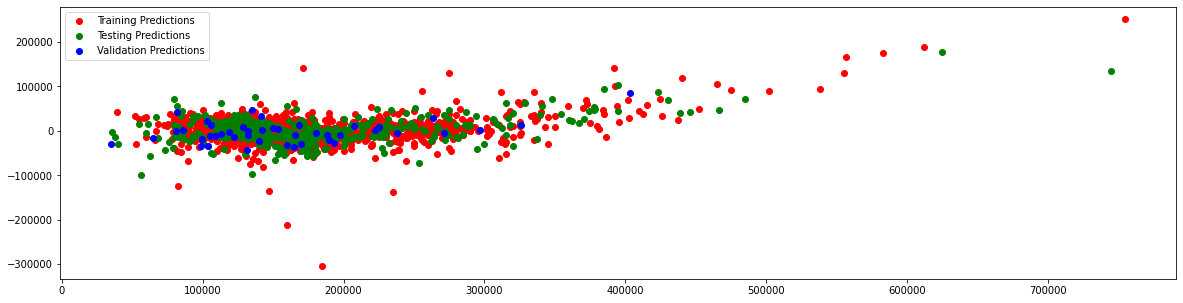

In [28]:
lr_perf = model_performance(model1,model_name = model1)

<h2>2. Ridge

In [29]:
model2 = Ridge(alpha = 0.01)
model2.fit(x_train,y_train)

Ridge(alpha=0.01)

Model Performance for: Ridge(alpha=0.01)

Training Score: 0.839
Testing Score: 0.886
Validation Score 1.0

Training Data Mean Squared Error: 960232408.047
Testing Data Mean Squared Error: 832981041.023
Validation Data Mean Squared Error: 559844645.671

Training Data Mean Absolute Error: 19448.464
Testing Data Mean Absolute Error: 21010.493
Validation Data Mean Absolute Error: 17552.849

Training Data r2_score: 0.839
Testing Data r2_score: 0.886
Validation Data r2_score: 0.89

Residual Analysis:


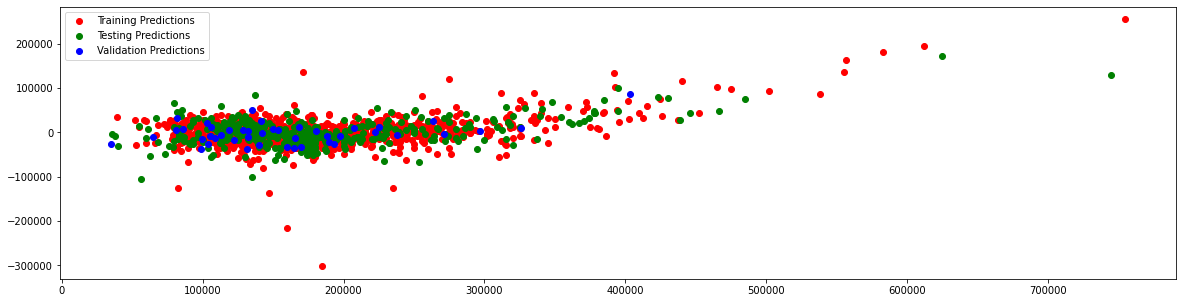

In [30]:
ridge_perf = model_performance(model2,model2)

<h2> 3. KNeighborsRegressor

In [31]:
model3 = KNeighborsRegressor(n_neighbors = 6)
model3.fit(x_train,y_train)

KNeighborsRegressor(n_neighbors=6)

Model Performance for: KNeighborsRegressor(n_neighbors=6)

Training Score: 0.804
Testing Score: 0.759
Validation Score 1.0

Training Data Mean Squared Error: 1166943306.155
Testing Data Mean Squared Error: 1767186348.37
Validation Data Mean Squared Error: 999927394.562

Training Data Mean Absolute Error: 20846.118
Testing Data Mean Absolute Error: 24537.066
Validation Data Mean Absolute Error: 23272.477

Training Data r2_score: 0.804
Testing Data r2_score: 0.759
Validation Data r2_score: 0.804

Residual Analysis:


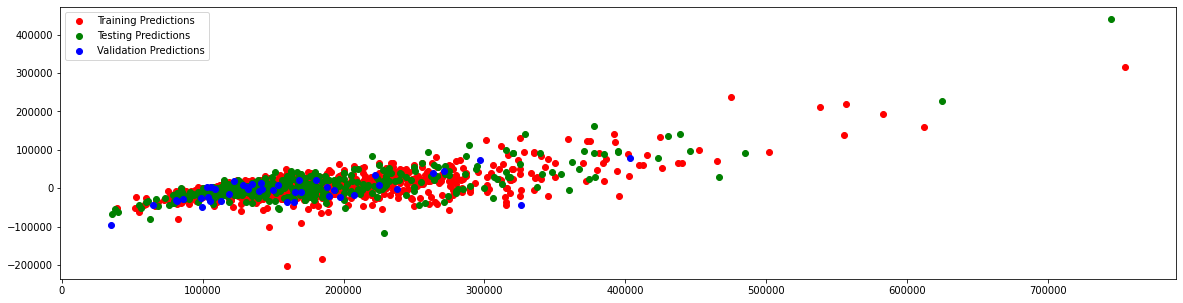

In [32]:
knn_perf = model_performance(model3,model3)

<h2>4. Decision Tree Classifier </h2>

In [33]:
param_grid = {'max_depth':np.arange(1,20),'min_samples_split':np.arange(2,10),'min_samples_leaf':np.arange(2,10)}
grid  = GridSearchCV(DecisionTreeRegressor(),param_grid = param_grid,cv = 5)
grid.fit(X,y)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                         'min_samples_leaf': array([2, 3, 4, 5, 6, 7, 8, 9]),
                         'min_samples_split': array([2, 3, 4, 5, 6, 7, 8, 9])})

In [34]:
grid.best_params_

{'max_depth': 12, 'min_samples_leaf': 8, 'min_samples_split': 9}

In [35]:
model4 = DecisionTreeRegressor(max_depth = 9,min_samples_leaf = 8,min_samples_split = 9)
model4.fit(x_train,y_train)

DecisionTreeRegressor(max_depth=9, min_samples_leaf=8, min_samples_split=9)

Model Performance for: DecisionTreeRegressor(max_depth=9, min_samples_leaf=8, min_samples_split=9)

Training Score: 0.88
Testing Score: 0.833
Validation Score 1.0

Training Data Mean Squared Error: 712173259.767
Testing Data Mean Squared Error: 1225701229.174
Validation Data Mean Squared Error: 821167850.103

Training Data Mean Absolute Error: 15846.741
Testing Data Mean Absolute Error: 23347.046
Validation Data Mean Absolute Error: 20963.945

Training Data r2_score: 0.88
Testing Data r2_score: 0.833
Validation Data r2_score: 0.839

Residual Analysis:


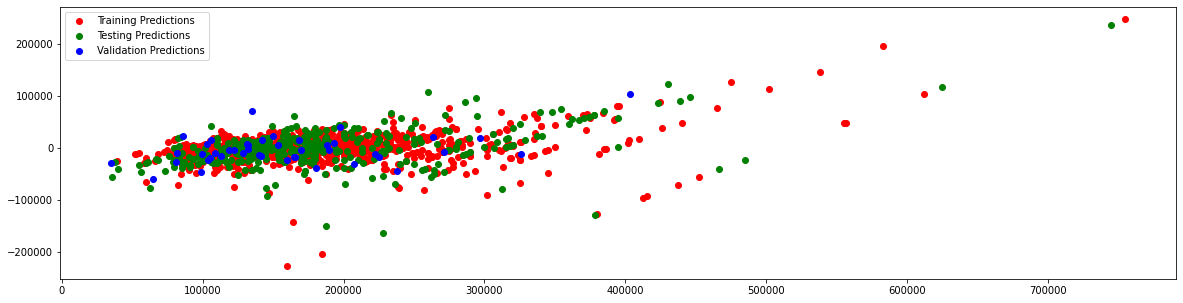

In [36]:
dt_perf = model_performance(model4,model4)

<h2> 5. RandomForest

In [37]:
model5 = RandomForestRegressor()
model5.fit(x_train,y_train)

RandomForestRegressor()

Model Performance for: RandomForestRegressor()

Training Score: 0.974
Testing Score: 0.911
Validation Score 1.0

Training Data Mean Squared Error: 154447932.008
Testing Data Mean Squared Error: 653953888.703
Validation Data Mean Squared Error: 508721852.999

Training Data Mean Absolute Error: 6855.828
Testing Data Mean Absolute Error: 17231.806
Validation Data Mean Absolute Error: 17021.521

Training Data r2_score: 0.974
Testing Data r2_score: 0.911
Validation Data r2_score: 0.9

Residual Analysis:


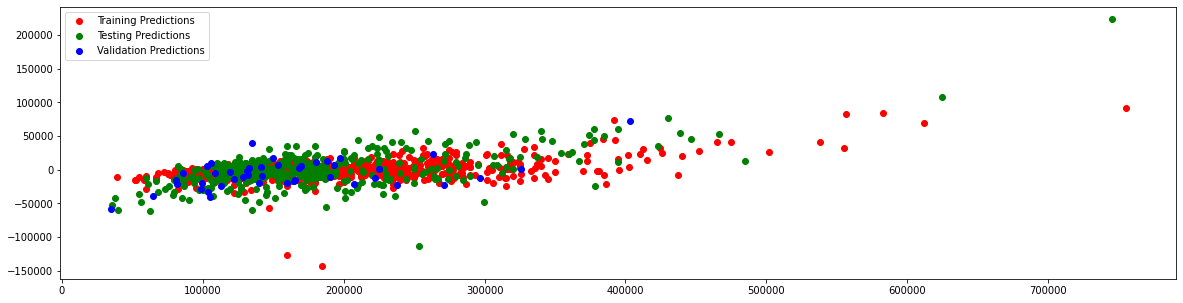

In [38]:
rf_perf = model_performance(model5,model5)

<h2>6. XGBoost

In [39]:
model6 = xgboost.XGBRegressor(colsample_bytree=0.4,gamma=0,learning_rate=0.07,max_depth=3,min_child_weight=1.5,n_estimators=10000,reg_alpha=0.75,reg_lambda=0.45,subsample=0.6,seed=42)
model6.fit(x_train,y_train)

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.4,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.07, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=1.5,
             missing=nan, monotone_constraints='()', n_estimators=10000,
             n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=42,
             reg_alpha=0.75, reg_lambda=0.45, ...)

Model Performance for: XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.4,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.07, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=1.5,
             missing=nan, monotone_constraints='()', n_estimators=10000,
             n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=42,
             reg_alpha=0.75, reg_lambda=0.45, ...)

Training Score: 1.0
Testing Score: 0.916
Validation Score 1.0

Training Data Mean Squared Error: 866.164
Testing Data Mean Squared Error: 614998649.112
Validation Data Mean Squared Error: 466184915.318

Training Data Mean Absolute Error: 17.189
Testing Data Mean Absolute Error: 15

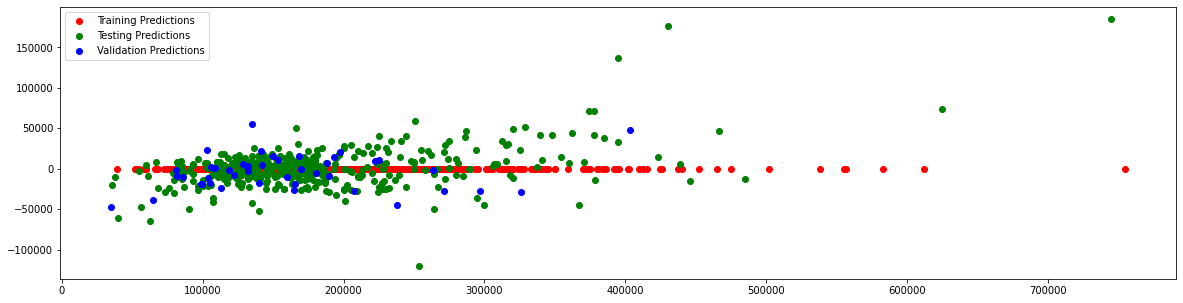

In [40]:
xgb_perf = model_performance(model6,model6)

# Creating a Model and Making Predictions for the competition

In [41]:
model = xgboost.XGBRegressor(colsample_bytree=0.4,gamma=0,learning_rate=0.07,max_depth=3,min_child_weight=1.5,n_estimators=10000,reg_alpha=0.75,reg_lambda=0.45,subsample=0.6,seed=42)
model.fit(X,y)

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.4,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.07, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=1.5,
             missing=nan, monotone_constraints='()', n_estimators=10000,
             n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=42,
             reg_alpha=0.75, reg_lambda=0.45, ...)

In [42]:
model2 = RandomForestRegressor()
model2.fit(X,y)

RandomForestRegressor()

In [43]:
prediction = model.predict(test)

In [44]:
prediction2 = model2.predict(test)

In [45]:
pred = (prediction+prediction2)/2

In [46]:
output = pd.DataFrame({'Id':pid,'SalePrice': prediction})
output.to_csv('House_prices.csv', index=False)

In [47]:
output

,Id,SalePrice
0,1461,151224.875000
1,1462,161866.718750
2,1463,183893.703125
3,1464,188083.625000
4,1465,170150.734375
...,...,...
1454,2915,72426.359375
1455,2916,88846.210938
1456,2917,177371.875000
1457,2918,131091.656250
